In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv('../data/q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Date-based features such as year, month, and day of week are extracted to capture temporal patterns in sales. Additionally, a binary feature is_month_end is created to account for potential increases in sales toward the end of the month.


In [4]:
df = df.sort_values(by='transaction_date')

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

A time-based split is used instead of a random split because the data is sequential in nature. Using a random split could lead to data leakage from future observations into the training set, resulting in overly optimistic model performance.


In [5]:
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first'), categorical_cols)
])

In [6]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [10]:
def evaluate_reg(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    
    # Parity plot
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} - Parity Plot")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()])
    plt.show()


Linear Regression
RMSE: 27.121451164890622
MAE: 21.052926674588395


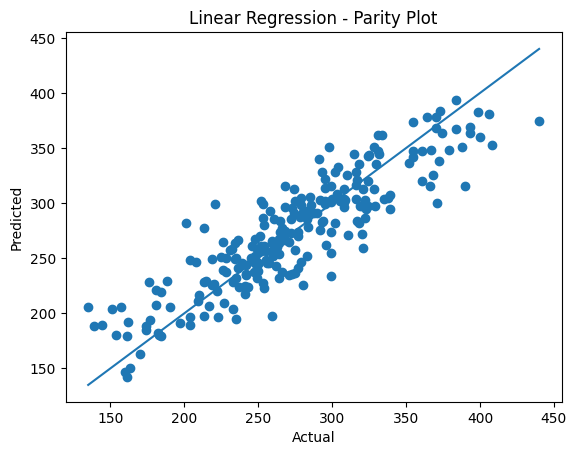


Random Forest
RMSE: 31.658897860633115
MAE: 24.904708333333335


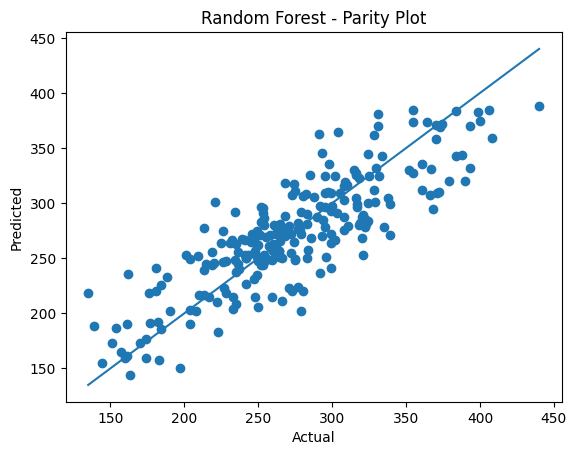

In [11]:
evaluate_reg(lr_pipeline, X_test, y_test, "Linear Regression")
evaluate_reg(rf_pipeline, X_test, y_test, "Random Forest")

The Linear Regression model outperforms the Random Forest Regressor, as it achieves lower RMSE and MAE values. This indicates that the linear model provides more accurate predictions for items sold in this dataset.

This suggests that the relationship between the features and the target variable is relatively linear, and the Random Forest model may be overfitting or not capturing additional complexity effectively.

The parity plots show that the predictions from the Linear Regression model are closer to the diagonal reference line compared to the Random Forest model, indicating better alignment between predicted and actual values.


In [9]:
rf_model = rf_pipeline.named_steps['model']

feature_names = (
    numerical_cols +
    list(rf_pipeline.named_steps['preprocessor']
         .transformers_[1][1]
         .get_feature_names_out(categorical_cols))
)

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(5)

,feature,importance
15,store_size_small,0.183953
2,is_festival,0.174490
13,location_type_urban,0.140494
6,day_of_week,0.087179
1,is_weekend,0.066870


The feature importance analysis from the Random Forest model shows that store size, festival indicators, and location type are the most influential factors affecting the number of items sold.

Specifically, smaller store size has a significant impact, likely due to differences in inventory or customer traffic. The is_festival feature indicates that sales increase during festive periods, highlighting the importance of seasonal demand. Additionally, urban locations contribute more to sales compared to other areas, suggesting higher customer activity.

Temporal features such as day of the week and whether it is a weekend also play an important role, reflecting variations in customer shopping behavior across different days.


The feature importance results from the Random Forest model highlight the most influential variables affecting items sold. These features can be used by the business to better understand key drivers of sales and optimize promotional strategies.
